In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, LeakyReLU, Activation
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import legacy, Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report

In [3]:
# Verify TensorFlow can access the GPU
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Check TensorFlow version
print(tf.__version__)

Num GPUs Available:  1
2.17.0


In [4]:
# Load in images

# Set the path to your dataset directory
dataset_path = 'Data'

# Create an ImageDataGenerator object
train_datagen = ImageDataGenerator(dtype = 'float32', preprocessing_function=preprocess_input, validation_split=0.2)

# Set the batch size
batch_size = 32

# Load training data from directory
train_data = train_datagen.flow_from_directory(
    directory=f'{dataset_path}/EXTRA/TRAINING_DATA',
    target_size=(224, 224),  # Resize all images to 224x224
    batch_size=batch_size,
    class_mode='binary',  # Use 'binary' for binary classification problems
    shuffle=True,
    seed=42,  # For reproducibility
    subset='training',  # Specify this part is for training
)

# Load validation data from the same directory
val_data = train_datagen.flow_from_directory(
    directory=f'{dataset_path}/EXTRA/TRAINING_DATA',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False, # optional for validation
    # seed=42,
    subset='validation',  # Specify this part is for validation
)

Found 74728 images belonging to 2 classes.
Found 18681 images belonging to 2 classes.


In [5]:
# check if any filenames same in both training and validation data
train_files = set(train_data.filenames)
val_files = set(val_data.filenames)
common_files = train_files.intersection(val_files)
print(f'Number of common files in training and validation data: {len(common_files)}')


Number of common files in training and validation data: 0


In [6]:
# check images data type
print(train_data[0][0].dtype)

float32


In [7]:
# print class names for each dataset
print('Training Data Classes:', train_data.class_indices)
print('Validation Data Classes:', val_data.class_indices)
# print('Testing Data Classes:', test_data.class_indices)

Training Data Classes: {'MSI': 0, 'MSS': 1}
Validation Data Classes: {'MSI': 0, 'MSS': 1}


In [8]:
# Print class distribution for each dataset

# Training Data
train_class_distribution = pd.Series(train_data.classes).value_counts()
print('Training Data Class Distribution:')
print(train_class_distribution)

# Validation Data
val_class_distribution = pd.Series(val_data.classes).value_counts()
print('Validation Data Class Distribution:')
print(val_class_distribution)

Training Data Class Distribution:
0    37364
1    37364
dtype: int64
Validation Data Class Distribution:
1    9341
0    9340
dtype: int64


## VGG-19 Model

In [9]:
from tensorflow.keras.applications import VGG19

# Load the VGG19 model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Model Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)  # L2 regularization
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Creating the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model summary to inspect the architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,600,321 (82.40 MB)

 Trainable params: 1,575,937 (6.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [10]:
# train resunet model with callbacks

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

history = model.fit(
    train_data,
    epochs=100,
    validation_data=val_data,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100


2024-08-01 03:13:01.859017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
/opt/homebrew/Caskroom/miniconda/base/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2336/2336 ━━━━━━━━━━━━━━━━━━━━ 840s 358ms/step - accuracy: 0.5988 - loss: 4.2683 - val_accuracy: 0.6955 - val_loss: 1.2273 - learning_rate: 1.0000e-04
Epoch 2/100
2336/2336 ━━━━━━━━━━━━━━━━━━━━ 866s 371ms/step - accuracy: 0.6474 - loss: 1.1017 - val_accuracy: 0.6961 - val_loss: 0.7890 - learning_rate: 1.0000e-04
Epoch 3/100
2336/2336 ━━━━━━━━━━━━━━━━━━━━ 894s 382ms/step - accuracy: 0.6572 - loss: 0.7816 - val_accuracy: 0.6983 - val_loss: 0.6773 - learning_rate: 1.0000e-04
Epoch 4/100
2336/2336 ━━━━━━━━━━━━━━━━━━━━ 963s 412ms/step - accuracy: 0.6689 - loss: 0.6878 - val_accuracy: 0.7101 - val_loss: 0.6295 - learning_rate: 1.0000e-04
Epoch 5/100
2336/2336 ━━━━━━━━━━━━━━━━━━━━ 844s 361ms/step - accuracy: 0.6763 - loss: 0.6510 - val_accuracy: 0.7223 - val_loss: 0.5962 - learning_rate: 1.0000e-04
Epoch 6/100
2336/2336 ━━━━━━━━━━━━━━━━━━━━ 872s 373ms/step - accuracy: 0.6846 - loss: 0.6276 - val_accuracy: 0.7237 - val_loss: 0.5966 - learning_rate: 1.0000e-04
Epoch 7/100
2336/2336 ━━━━━━━━━━━━

In [11]:
# evaluate the model
test_loss, test_accuracy = model.evaluate(val_data)
print(f"Test Accuracy: {test_accuracy}")

584/584 ━━━━━━━━━━━━━━━━━━━━ 179s 306ms/step - accuracy: 0.7997 - loss: 0.4372
Test Accuracy: 0.798725962638855


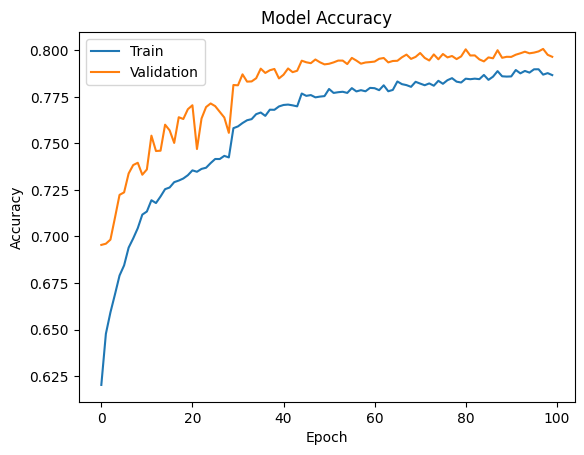

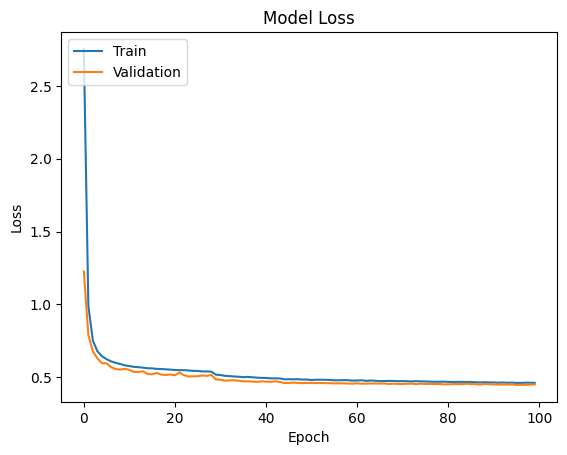

In [12]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plot training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [13]:
# get model evaluation metrics: F1 score, precision, recall

# make predictions on the test set
predictions = model.predict(val_data)
# convert predictions to binary
binary_predictions = np.where(predictions > 0.5, 1, 0)

# get classification report
report = classification_report(val_data.classes, binary_predictions)
print(report)

584/584 ━━━━━━━━━━━━━━━━━━━━ 187s 320ms/step
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      9340
           1       0.80      0.80      0.80      9341

    accuracy                           0.80     18681
   macro avg       0.80      0.80      0.80     18681
weighted avg       0.80      0.80      0.80     18681



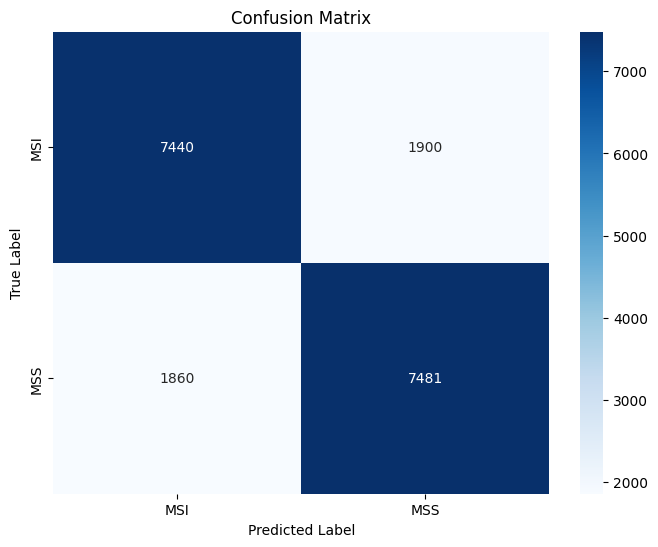

In [14]:
# import seaborn and confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

# get confusion matrix
cm = confusion_matrix(val_data.classes, binary_predictions)

# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_data.class_indices, yticklabels=val_data.class_indices)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
# sensitivity and specificity
# sensitivity = TP / (TP + FN)
# specificity = TN / (TN + FP)

# get true positive, true negative, false positive, false negative
TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]

# calculate sensitivity and specificity
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f'Sensitivity: {sensitivity}')
print(f'Specificity: {specificity}')

Sensitivity: 0.800877850337223
Specificity: 0.7965738758029979


In [16]:
# get AUC-ROC score
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(val_data.classes, binary_predictions)
print(f'AUC-ROC Score: {roc_auc}')

AUC-ROC Score: 0.7987258630701105


In [ ]:
# save model as resunet_model in tf format

# model.save('resnet_model_final', save_format='tf')

## Additional Results

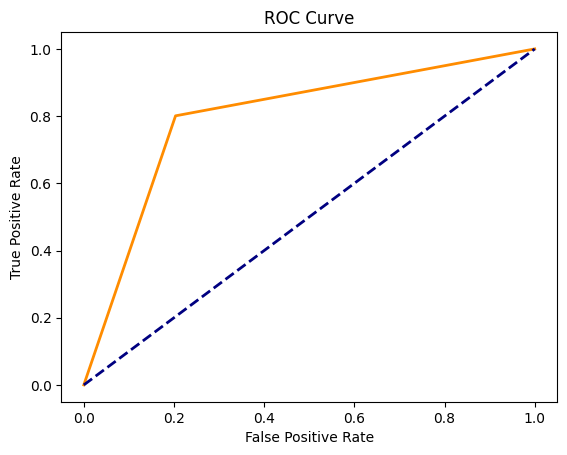

In [17]:
# plot ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(val_data.classes, binary_predictions)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [18]:
# create function to calculate Matthew’s correlation coefficient

def calculate_mcc(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    tp = conf_matrix[0, 0]
    tn = conf_matrix[1, 1]
    fp = conf_matrix[0, 1]
    fn = conf_matrix[1, 0]
    mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return mcc

In [19]:
# use function to calculate MCC
mcc = calculate_mcc(val_data.classes, binary_predictions)
print(f'MCC: {mcc}')

MCC: 0.5974573415641345
